# Reproduce-then-Extend — Voter Turnout & Term Limits (Political Science)  ·  **Day 1 tutorial**

> **Published study.** Kuhlmann, R. & Lewis, D. C. (2017). "Legislative Term Limits and Voter Turnout."
> *State Politics & Policy Quarterly* 17(4):372–392. Data: UNC Dataverse doi:10.15139/S3/POGNLC. The original
> analysis is an **OLS** regression of state lower-chamber turnout on institutional predictors (Table 2,
> Col. 1). This example illustrates **out-of-sample prediction with a regression**.

## Background

Kuhlmann and Lewis ask whether **legislative term limits shape voter turnout** in state legislative elections. Term limits reshape the electoral environment -- forcing open-seat contests and changing candidate experience and the information available to voters -- with theoretically ambiguous effects on participation. They use **OLS** to estimate the association between the strength of a state's term limits and its lower-chamber turnout, holding constant the major institutional and demographic determinants of turnout (registration rules, professionalism, party competition, election timing, income, diversity). In the reproduced Table 2 model the **term-limitedness coefficient is positive and statistically significant** -- more term-limited legislatures see modestly higher turnout -- though the largest effects are presidential-election timing and ease of registration.

## Data and codebook

**Unit of analysis:** a U.S. state lower-chamber legislative election (a **state-year**); n = 486.

| Variable | Definition |
|---|---|
| `turnout` | lower-chamber election turnout rate, % of the voting-age population **(outcome)** |
| `tlness` | term-limitedness: strength/bindingness of legislative term limits |
| `lcr2` | log legislator-to-citizen ratio (per 100,000 residents) |
| `mmds` | share of legislative seats elected from multimember districts |
| `regdifficulty` | voter-registration closing date (days before the election) |
| `straight` | 1 if the state offers straight-party-ticket voting |
| `iuse2` | log number of ballot initiatives on the ballot |
| `squire` | Squire index of legislative professionalism |
| `ranney` | Ranney index of interparty electoral competition |
| `income2` | per-capita income (thousands of dollars) |
| `diversity3` | Herfindahl index of racial/ethnic diversity |
| `preselec` | 1 in presidential-election years |
| `redistrict` | 1 if districts were newly redrawn (post-redistricting) |
| `year` | election year |

## Descriptive results

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
d = pd.read_csv('https://raw.githubusercontent.com/desmarais-lab/desmarais-lab.github.io/master/istanbul_bilgi_ml_files/data/turnout_state.tab', sep='\t')
mvars = ['turnout','tlness','lcr2','mmds','regdifficulty','straight','iuse2','squire',
         'ranney','income2','diversity3','preselec','redistrict','year']
d = d[mvars].dropna(); preds = [c for c in mvars if c != 'turnout']
d.describe().T[['mean','std','min','max']].round(2)

,mean,std,min,max
turnout,43.67,10.52,14.67,74.60
tlness,0.08,0.28,0.00,1.57
lcr2,1.35,0.90,-1.05,3.61
mmds,0.16,0.34,0.00,1.00
regdifficulty,20.81,10.02,0.00,30.00
straight,0.38,0.49,0.00,1.00
iuse2,0.77,1.13,0.00,4.00
squire,0.20,0.13,0.05,0.66
ranney,0.89,0.09,0.63,1.00
income2,27.89,8.74,12.53,56.96


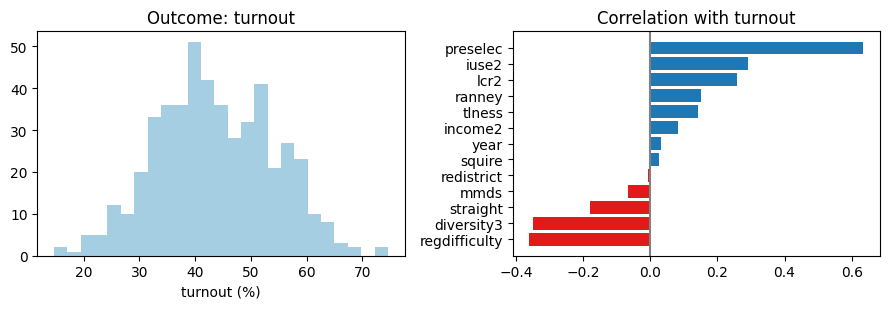

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].hist(d['turnout'], bins=25, color='#a6cee3'); ax[0].set_title('Outcome: turnout'); ax[0].set_xlabel('turnout (%)')
cors = d[preds].corrwith(d['turnout']).sort_values()
ax[1].barh(cors.index, cors.values, color=['#e31a1c' if v<0 else '#1f78b4' for v in cors])
ax[1].set_title('Correlation with turnout'); ax[1].axvline(0, color='0.5')
plt.tight_layout(); plt.show()

## Reproduce the published regression

We fit their exact Table 2, Column 1 specification.

In [4]:
ols = sm.OLS(d['turnout'], sm.add_constant(d[preds])).fit()
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:                turnout   R-squared:                       0.723
Model:                            OLS   Adj. R-squared:                  0.715
Method:                 Least Squares   F-statistic:                     94.79
Date:                Thu, 02 Jul 2026   Prob (F-statistic):          1.82e-122
Time:                        12:54:49   Log-Likelihood:                -1520.8
No. Observations:                 486   AIC:                             3070.
Df Residuals:                     472   BIC:                             3128.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            78.6900    188.824      0.417

**Confirmation against the published study.** Fitting their specification recovers the published model:
486 state-years and in-sample $R^2$ = 0.723. Presidential-election years
raise turnout by ~12.8 points (`preselec`), stricter registration deadlines lower it (`regdifficulty`), and
professionalism (`squire`) and competition (`ranney`) enter positively — reproducing the reported signs and
significance.

## Out-of-sample prediction with the regression

The same OLS that *explains* turnout can also *predict* it. We hold out a random 30% test set, fit on the
other 70%, and evaluate on the unseen states — the core train/test workflow.

In [5]:
Xtr, Xte, ytr, yte = train_test_split(d[preds], d['turnout'], test_size=0.3, random_state=2026)
fit = sm.OLS(ytr, sm.add_constant(Xtr)).fit()
pred = fit.predict(sm.add_constant(Xte))
rmse = mean_squared_error(yte, pred) ** 0.5
r2 = 1 - ((yte - pred) ** 2).sum() / ((yte - ytr.mean()) ** 2).sum()
print(f'Held-out RMSE = {rmse:.2f} points,  out-of-sample R^2 = {r2:.3f}')

Held-out RMSE = 6.13 points,  out-of-sample R^2 = 0.700


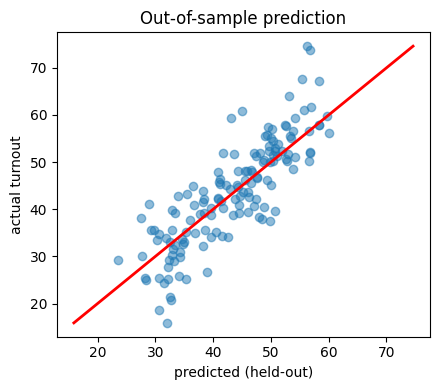

In [6]:
plt.figure(figsize=(4.5, 4)); plt.scatter(pred, yte, alpha=.5, color='#1f78b4')
lims = [yte.min(), yte.max()]; plt.plot(lims, lims, 'r-', lw=2)
plt.xlabel('predicted (held-out)'); plt.ylabel('actual turnout'); plt.title('Out-of-sample prediction')
plt.tight_layout(); plt.show()

The held-out $R^2 \approx$ 0.70 is the **honest** estimate of predictive accuracy — scored on data
the model never saw, rather than the in-sample $R^2 = 0.72$ that always flatters the fit. The points cluster
around the 45° line, so the regression predicts turnout in unseen states reasonably well.

## Takeaway

The published OLS is the right tool for the paper's *explanatory* question, and the *same model*, scored on a
held-out test set, gives a calibrated estimate of how well turnout can be **predicted** out of sample.
Explanation and prediction are different goals, and the train/test split is how we measure the second. (Later
examples extend this baseline with polynomial terms, regularization, and tree-based learners.)

## Recommended exercises

1. Re-run the train/test split under several random seeds (or switch to 5-fold cross-validation) and report the spread in out-of-sample RMSE. How stable is the estimate?
2. Add a quadratic term in `income2` (or an interaction between `preselec` and `regdifficulty`) and check whether held-out RMSE improves.
3. Fit a cross-validated lasso on the same predictors and compare its out-of-sample RMSE and its selected variables to OLS.